# DBSCAN on `train_dim12.json`

This notebook is a clean DBSCAN pipeline for the 12D speech features.

It is designed to answer four practical questions:
1. Why does the number of frames vary by utterance?
2. What does `sil` mean?
3. Why is clustering useful here?
4. How do we run DBSCAN with objective evaluation and t-SNE visualization?


## Quick Concept Notes

Why is the number of frames not always `349`?
- `349` is only the first utterance example you inspected.
- Each utterance has a different duration, so after framing the waveform into short windows, each utterance gets a different number of frames `T`.
- Shorter audio gives smaller `T`; longer audio gives larger `T`.

What is `sil`?
- `sil` means **silence** or non-speech pause.
- It usually appears at the beginning/end of utterances and between spoken regions.
- It is common and often longer than many phone segments, so it can dominate clustering if we leave it in.

Why can clustering be useful here?
- It lets you test whether the acoustic representation groups similar speech units without using full supervision to train a classifier.
- It can reveal whether some phones are naturally separable and which ones overlap acoustically.
- It is useful as an analysis tool even if it is not the final modeling approach.

What was done in `clustering.ipynb`?
- It mostly built segment centroids from predicted boundaries.
- It used `train.json` / `dev.json` 39D features and context-windowed 429D features.
- It then ran **KMeans**, not DBSCAN, and visualized KMeans labels with t-SNE.
- So it is not the notebook to use if you want a clean DBSCAN study on `train_dim12.json`.


In [1]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
    v_measure_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

with open("train_dim12.json", "r") as f:
    data = json.load(f)

print("num utterances:", len(data))


num utterances: 4620


## Utterance Length EDA

The number of frames varies because utterances have different durations.

If the feature extraction uses short overlapping windows, then:
- longer speech -> more frames
- shorter speech -> fewer frames


,quantity,value
0,num_utterances,4620.00
1,min_frames,92.00
2,median_frames,296.00
3,mean_frames,307.73
4,max_frames,779.00


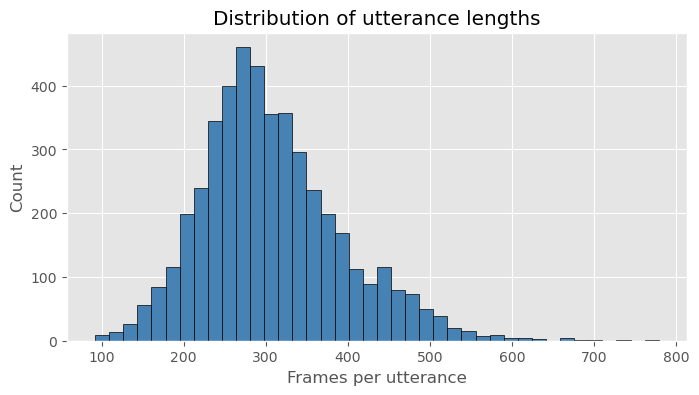

In [2]:
frame_lengths = np.array([len(v["features"]) for v in data.values()])

summary_df = pd.DataFrame([
    {"quantity": "num_utterances", "value": len(frame_lengths)},
    {"quantity": "min_frames", "value": int(frame_lengths.min())},
    {"quantity": "median_frames", "value": float(np.median(frame_lengths))},
    {"quantity": "mean_frames", "value": round(float(frame_lengths.mean()), 2)},
    {"quantity": "max_frames", "value": int(frame_lengths.max())},
])

display(summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(frame_lengths, bins=40, color="steelblue", edgecolor="black")
ax.set_title("Distribution of utterance lengths")
ax.set_xlabel("Frames per utterance")
ax.set_ylabel("Count")
plt.show()


## Build Segment-Level Examples

DBSCAN on raw frames is usually a poor fit here because adjacent frames are highly correlated and phoneme segments span multiple frames.

So we build one example per phoneme segment using `phn_transcript`.

Default representation in this notebook:
- `mean12`
- `std12`
- `log_duration`

This is stronger than `mean12` alone and still easy to inspect.


In [12]:
def build_segment_table(dataset, min_duration=3, drop_sil=True):
    rows = []
    skipped = 0

    for utt_id, utt in dataset.items():
        feats = np.asarray(utt["features"], dtype=np.float32)
        T = feats.shape[0]
        transcript = utt["phn_transcript"]

        for seg_idx, (label, start, end) in enumerate(transcript):
            start = int(start)
            end = int(end)

            # Some utterances use T-1 for the final endpoint.
            if seg_idx == len(transcript) - 1 and end == T - 1:
                end = T

            start = max(start, 0)
            end = min(end, T)
            duration = end - start

            if end <= start:
                skipped += 1
                continue
            if drop_sil and label == "sil":
                continue
            if duration < min_duration:
                continue

            seg = feats[start:end]
            rows.append({
                "utt_id": utt_id,
                "seg_idx": seg_idx,
                "label": label,
                "start": start,
                "end": end,
                "duration": duration,
                "mean12": seg.mean(axis=0),
                "std12": seg.std(axis=0),
                "log_duration": float(np.log1p(duration)),
            })

    return pd.DataFrame(rows), skipped

segment_df, skipped_segments = build_segment_table(data, min_duration=3, drop_sil=True)

X = np.hstack([
    np.stack(segment_df["mean12"].to_numpy()),
    np.stack(segment_df["std12"].to_numpy()),
    segment_df[["log_duration"]].to_numpy(),
])
y = segment_df["label"].to_numpy()

print("usable non-silence segments:", len(segment_df))
print("skipped invalid segments:", skipped_segments)
print("feature matrix shape:", X.shape)
print("unique phoneme labels:", len(np.unique(y)))
print("top 15 labels:", Counter(y).most_common(15))


usable non-silence segments: 125736
skipped invalid segments: 83
feature matrix shape: (125736, 25)
unique phoneme labels: 38
top 15 labels: [('ih', 13254), ('n', 8064), ('s', 7475), ('iy', 6949), ('l', 6626), ('r', 6261), ('aa', 6001), ('ah', 5934), ('er', 5441), ('ae', 3997), ('k', 3988), ('eh', 3848), ('m', 3775), ('z', 3769), ('t', 3554)]


## Standardize Features

DBSCAN is distance-based, so scaling is mandatory.

Without scaling, large-magnitude coefficients dominate the distance computation.


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_stats = pd.DataFrame({
    "dim": np.arange(X.shape[1]),
    "raw_std": X.std(axis=0),
    "scaled_std": X_scaled.std(axis=0),
})

display(feature_stats.head(10))


,dim,raw_std,scaled_std
0,0,70.167259,1.0
1,1,61.404599,1.0
2,2,34.838315,1.0
3,3,31.441800,1.0
4,4,23.607118,1.0
5,5,18.268474,1.0
6,6,16.194571,1.0
7,7,16.288004,1.0
8,8,12.949885,1.0
9,9,13.412766,1.0


## Use a Fixed Subset for Tuning

DBSCAN hyperparameter tuning is expensive on the full dataset, so we first tune on a reproducible subset.

Later, once a promising setting is found, you can rerun on more points.


In [14]:
rng = np.random.default_rng(0)
subset_size = min(15000, len(X_scaled))
subset_idx = rng.choice(len(X_scaled), size=subset_size, replace=False)

X_sub = X_scaled[subset_idx]
y_sub = y[subset_idx]
segment_sub_df = segment_df.iloc[subset_idx].reset_index(drop=True)

print("subset size:", len(X_sub))
print("subset label distribution top 15:", Counter(y_sub).most_common(15))


subset size: 15000
subset label distribution top 15: [('ih', 1540), ('n', 911), ('s', 898), ('iy', 896), ('l', 780), ('aa', 746), ('r', 733), ('ah', 700), ('er', 619), ('k', 485), ('ae', 476), ('eh', 467), ('m', 452), ('z', 444), ('t', 409)]


## Heuristic Search for `eps` Using k-Distance Curves

DBSCAN needs two main hyperparameters:
- `min_samples` (sometimes informally called number of neighbors)
- `eps` (maximum neighborhood radius)

A common heuristic is:
1. choose candidate `min_samples`
2. compute the distance to each point's `k`-th nearest neighbor
3. sort those distances
4. look for the elbow region

That elbow gives a plausible range for `eps`.


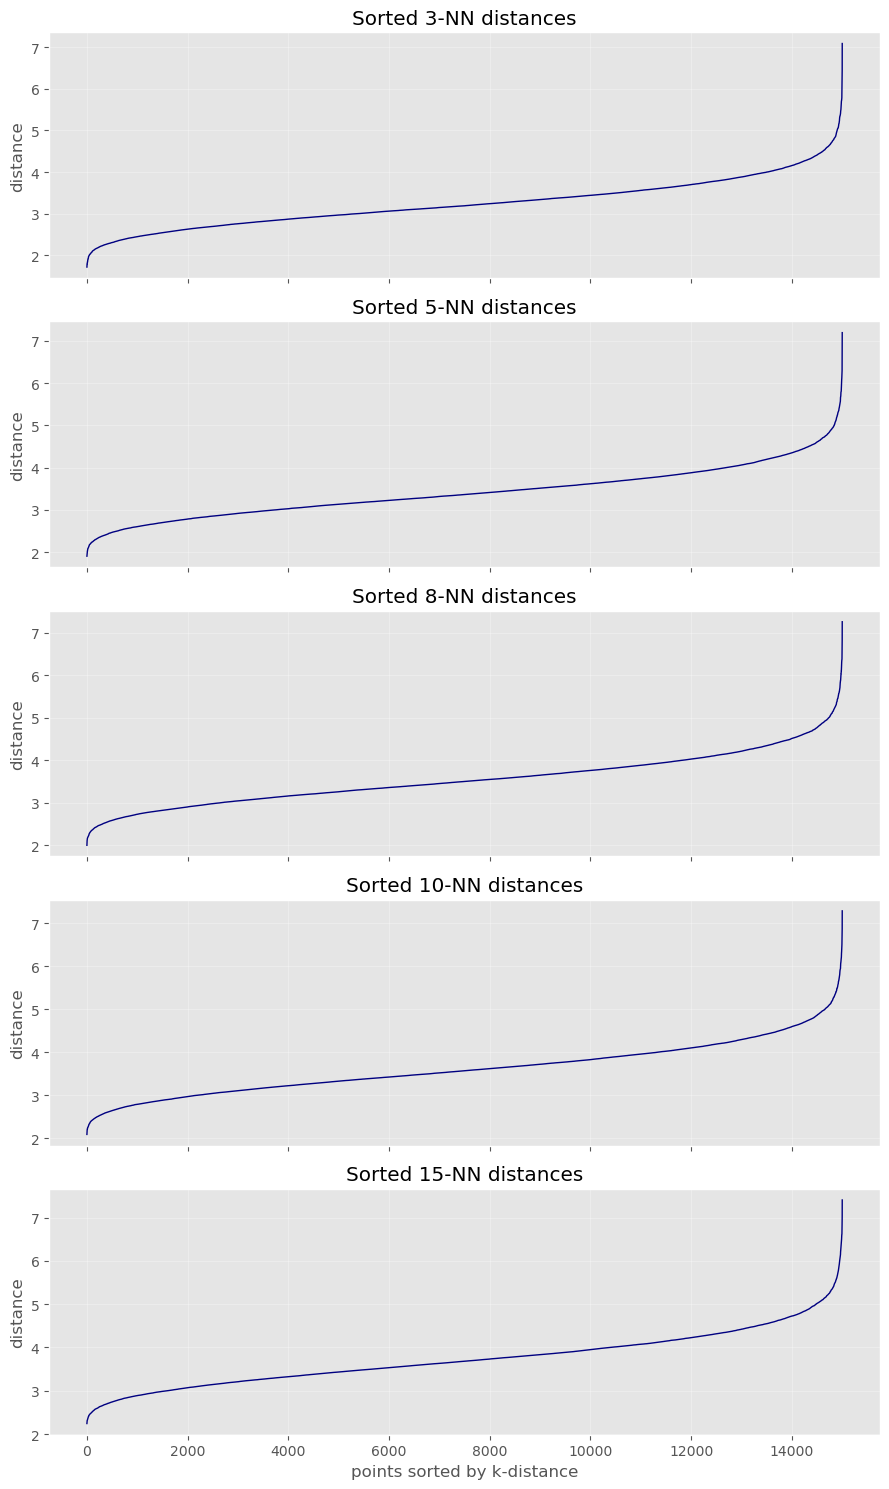

,min_samples,q90,q95,q97,q98,q99
0,3,3.9984,4.2698,4.4504,4.5966,4.8229
1,5,4.1973,4.4557,4.6434,4.7813,5.0319
2,8,4.3480,4.6262,4.8245,4.9644,5.2381
3,10,4.4209,4.6998,4.9049,5.0464,5.3219
4,15,4.5484,4.8393,5.0542,5.2016,5.4835


In [15]:
candidate_min_samples = [3, 5, 8, 10, 15]
kdist_lookup = {}
summary_rows = []

fig, axes = plt.subplots(len(candidate_min_samples), 1, figsize=(9, 3 * len(candidate_min_samples)), sharex=True)

for ax, k in zip(axes, candidate_min_samples):
    nn = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nn.fit(X_sub)
    distances, _ = nn.kneighbors(X_sub)
    kdist = np.sort(distances[:, -1])
    kdist_lookup[k] = kdist

    q90, q95, q97, q98, q99 = np.quantile(kdist, [0.90, 0.95, 0.97, 0.98, 0.99])
    summary_rows.append({
        "min_samples": k,
        "q90": round(float(q90), 4),
        "q95": round(float(q95), 4),
        "q97": round(float(q97), 4),
        "q98": round(float(q98), 4),
        "q99": round(float(q99), 4),
    })

    ax.plot(kdist, color="navy", linewidth=1)
    ax.set_title(f"Sorted {k}-NN distances")
    ax.set_ylabel("distance")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("points sorted by k-distance")
plt.tight_layout()
plt.show()

kdist_summary_df = pd.DataFrame(summary_rows)
display(kdist_summary_df)


## Hyperparameter Sweep

We now sweep over a grid of:
- `min_samples`
- `eps`

Objective metrics reported:
- `coverage`: fraction of points not labeled as noise
- `AMI_all`, `NMI_all`, `ARI_all`: agreement with phoneme labels on the whole subset
- `clustered_purity`: majority-label purity over only clustered points
- `mapped_accuracy_all`: assign each cluster its majority phoneme and measure accuracy over all points

Important interpretation rule:
- high purity with tiny coverage is not a good result
- the best setting should improve agreement metrics **and** retain a meaningful number of points


In [7]:
def evaluate_dbscan(y_true, cluster_labels):
    clustered_mask = cluster_labels >= 0
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    coverage = float(clustered_mask.mean())

    out = {
        "n_clusters": int(n_clusters),
        "coverage": round(coverage, 4),
        "noise_fraction": round(float((cluster_labels == -1).mean()), 4),
        "AMI_all": round(adjusted_mutual_info_score(y_true, cluster_labels), 4),
        "NMI_all": round(normalized_mutual_info_score(y_true, cluster_labels), 4),
        "ARI_all": round(adjusted_rand_score(y_true, cluster_labels), 4),
    }

    if clustered_mask.any() and n_clusters > 0:
        clustered_df = pd.DataFrame({
            "cluster": cluster_labels[clustered_mask],
            "phoneme": y_true[clustered_mask],
        })
        majority_count = clustered_df.groupby("cluster")["phoneme"].agg(lambda s: s.value_counts().iloc[0])
        cluster_size = clustered_df.groupby("cluster").size()
        clustered_purity = float(majority_count.sum() / cluster_size.sum())

        majority_label = clustered_df.groupby("cluster")["phoneme"].agg(lambda s: s.value_counts().index[0])
        mapped_pred = np.array([
            majority_label[c] if c >= 0 else "__noise__"
            for c in cluster_labels
        ])

        out.update({
            "homogeneity_clustered": round(homogeneity_score(y_true[clustered_mask], cluster_labels[clustered_mask]), 4),
            "completeness_clustered": round(completeness_score(y_true[clustered_mask], cluster_labels[clustered_mask]), 4),
            "v_measure_clustered": round(v_measure_score(y_true[clustered_mask], cluster_labels[clustered_mask]), 4),
            "clustered_purity": round(clustered_purity, 4),
            "mapped_accuracy_all": round(float((mapped_pred == y_true).mean()), 4),
            "mapped_accuracy_clustered": round(float((mapped_pred[clustered_mask] == y_true[clustered_mask]).mean()), 4),
        })
    else:
        out.update({
            "homogeneity_clustered": np.nan,
            "completeness_clustered": np.nan,
            "v_measure_clustered": np.nan,
            "clustered_purity": np.nan,
            "mapped_accuracy_all": np.nan,
            "mapped_accuracy_clustered": np.nan,
        })

    return out

# You can edit this grid after looking at the k-distance curves above.
param_grid = {
    3:  [0.8, 1.0, 1.2, 1.4, 1.6],
    5:  [1.0, 1.2, 1.4, 1.6, 1.8],
    8:  [1.2, 1.4, 1.6, 1.8, 2.0],
    10: [1.2, 1.4, 1.6, 1.8, 2.0],
    15: [1.4, 1.6, 1.8, 2.0, 2.2],
}

sweep_rows = []
for min_samples, eps_values in param_grid.items():
    for eps in eps_values:
        cluster_labels = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            algorithm="ball_tree",
        ).fit_predict(X_sub)

        row = {
            "eps": eps,
            "min_samples": min_samples,
        }
        row.update(evaluate_dbscan(y_sub, cluster_labels))
        row["selection_score"] = round(row["AMI_all"] * row["coverage"], 6)
        sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows).sort_values(
    ["selection_score", "AMI_all", "coverage"],
    ascending=False,
).reset_index(drop=True)

display(sweep_df)


,eps,min_samples,n_clusters,coverage,noise_fraction,AMI_all,NMI_all,ARI_all,homogeneity_clustered,completeness_clustered,v_measure_clustered,clustered_purity,mapped_accuracy_all,mapped_accuracy_clustered,selection_score
0,0.8,3,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,1.0,3,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,1.2,3,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,1.4,3,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,1.6,3,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,1.0,5,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,1.2,5,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,1.4,5,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,1.6,5,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
9,1.8,5,0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


## Choose the Best Hyperparameters

Here I select the best run by:
- first maximizing `AMI_all * coverage`
- then preferring larger `AMI_all`
- then preferring larger `coverage`

This is not mathematically sacred. It is a practical way to avoid picking a trivially tiny but pure cluster set.


In [8]:
best_row = sweep_df.iloc[0]
selected_eps = float(best_row["eps"])
selected_min_samples = int(best_row["min_samples"])

print("selected eps:", selected_eps)
print("selected min_samples:", selected_min_samples)
display(best_row.to_frame().T)

cluster_labels = DBSCAN(
    eps=selected_eps,
    min_samples=selected_min_samples,
    algorithm="ball_tree",
).fit_predict(X_sub)
clustered_mask = cluster_labels >= 0
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)


selected eps: 0.8
selected min_samples: 3


,eps,min_samples,n_clusters,coverage,noise_fraction,AMI_all,NMI_all,ARI_all,homogeneity_clustered,completeness_clustered,v_measure_clustered,clustered_purity,mapped_accuracy_all,mapped_accuracy_clustered,selection_score
0,0.8,3.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0


## Cluster Summary and Per-Phoneme Coverage

This tells you:
- which clusters are largest
- which phoneme dominates each cluster
- which phonemes DBSCAN is recovering at all


In [10]:
clustered_df = pd.DataFrame({
    "cluster": cluster_labels[clustered_mask],
    "phoneme": y_sub[clustered_mask],
})

cluster_summary = []
for cluster_id, count in clustered_df["cluster"].value_counts().items():
    label_counts = clustered_df.loc[clustered_df["cluster"] == cluster_id, "phoneme"].value_counts()
    cluster_summary.append({
        "cluster": int(cluster_id),
        "size": int(count),
        "top_label": label_counts.index[0],
        "top_label_fraction": round(float(label_counts.iloc[0] / count), 3),
        "top_3_labels": dict(label_counts.head(3)),
    })

cluster_summary_df = pd.DataFrame(cluster_summary).sort_values("size", ascending=False)
display(cluster_summary_df)

phoneme_rows = []
for phoneme in sorted(np.unique(y_sub)):
    phone_mask = y_sub == phoneme
    phoneme_rows.append({
        "phoneme": phoneme,
        "count": int(phone_mask.sum()),
        "clustered_fraction": round(float(clustered_mask[phone_mask].mean()), 4),
    })

phoneme_coverage_df = pd.DataFrame(phoneme_rows).sort_values(["clustered_fraction", "count"], ascending=[False, False])
display(phoneme_coverage_df.head(20))


KeyError: 'size'

## t-SNE Visualization

The embedding below is only for visualization.

Two plots are shown:
- same t-SNE embedding colored by DBSCAN cluster
- same t-SNE embedding colored by phoneme label

Interpretation:
- if DBSCAN clusters form clear islands and those islands mostly correspond to one phone family, the representation is helping
- if colors are heavily mixed, the representation is still weak for phoneme clustering


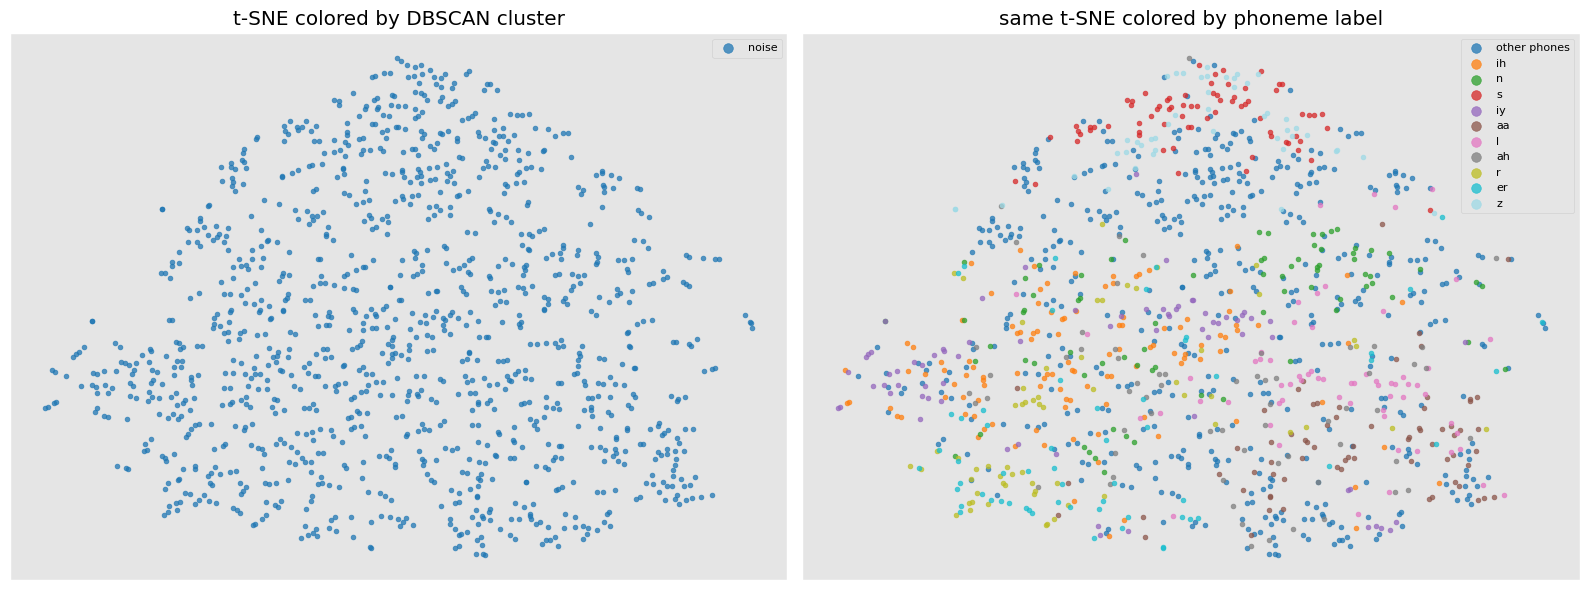

In [11]:
viz_pool = np.where(clustered_mask)[0] if clustered_mask.sum() > 0 else np.arange(len(X_sub))
viz_size = min(1200, len(viz_pool))
viz_idx = rng.choice(viz_pool, size=viz_size, replace=False)

X_viz = X_sub[viz_idx]
cluster_viz = cluster_labels[viz_idx]
phone_viz = y_sub[viz_idx]

tsne = TSNE(
    n_components=2,
    init="pca",
    method="exact",
    learning_rate="auto",
    perplexity=min(30, max(5, viz_size // 100)),
    random_state=0,
)
X_tsne = tsne.fit_transform(X_viz)

cluster_counts = pd.Series(cluster_viz).value_counts()
top_cluster_ids = [cid for cid in cluster_counts.index if cid != -1][:8]
cluster_names = np.array([
    "noise" if cid == -1 else (f"cluster {cid}" if cid in top_cluster_ids else "other clusters")
    for cid in cluster_viz
])

phone_counts = pd.Series(phone_viz).value_counts()
top_phone_labels = list(phone_counts.index[:10])
phone_names = np.array([
    p if p in top_phone_labels else "other phones"
    for p in phone_viz
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_categories = list(pd.Series(cluster_names).value_counts().index)
cluster_cmap = plt.get_cmap("tab10", max(1, len(cluster_categories)))
for i, category in enumerate(cluster_categories):
    mask = cluster_names == category
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=12, alpha=0.75, color=cluster_cmap(i), label=category)
axes[0].set_title("t-SNE colored by DBSCAN cluster")
axes[0].legend(markerscale=2, fontsize=8)

phone_categories = list(pd.Series(phone_names).value_counts().index)
phone_cmap = plt.get_cmap("tab20", max(1, len(phone_categories)))
for i, category in enumerate(phone_categories):
    mask = phone_names == category
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=12, alpha=0.75, color=phone_cmap(i), label=category)
axes[1].set_title("same t-SNE colored by phoneme label")
axes[1].legend(markerscale=2, fontsize=8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## What To Change If Results Are Weak

If the best run still has:
- very low `coverage`
- very low `AMI_all` / `ARI_all`
- only a few phones showing up in `phoneme_coverage_df`

then try these in order:
1. change `min_duration` in `build_segment_table` from `3` to `4` or `5`
2. compare `mean12` only vs `mean12 + std12 + log_duration`
3. keep `sil` excluded for tuning
4. widen the `eps` grid using the k-distance summary
5. if DBSCAN still rejects most points as noise, consider HDBSCAN or agglomerative clustering
